In [ ]:
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns


df_all_ECB_speeches = pd.read_csv(
    "all_ECB_speeches.csv",
    sep="|",
    encoding="utf-8",
    dtype=str
)

df_all_ECB_speeches["date"] = pd.to_datetime(
    df_all_ECB_speeches["date"], errors="coerce"
)

In [6]:
df_all_ECB_speeches["year"] = df_all_ECB_speeches["date"].dt.year

# Drop rows where date parsing failed
df_all_ECB_speeches = df_all_ECB_speeches.dropna(subset=["year"])

# Keep last 20 years
max_year = df_all_ECB_speeches["year"].max()
df_all_ECB_speeches = df_all_ECB_speeches[
    df_all_ECB_speeches["year"] >= max_year - 20
]

df_all_ECB_speeches["year"].value_counts().sort_index()

year
2006    105
2007    127
2008    142
2009    119
2010    129
2011    136
2012    104
2013    140
2014    107
2015    108
2016    113
2017    150
2018    117
2019    112
2020     95
2021    100
2022     99
2023    104
2024    109
2025    113
2026      4
Name: count, dtype: int64

In [7]:
df_all_ECB_speeches.columns

Index(['date', 'speakers', 'title', 'subtitle', 'contents', 'year'], dtype='object')

In [8]:
documents = df_all_ECB_speeches["contents"].astype(str).tolist()

len(documents)

2333

In [ ]:


def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

processed_docs = [preprocess(doc) for doc in documents]

processed_docs[0][:500]

'nan'

In [10]:
df_all_ECB_speeches["contents"].isna().sum()

np.int64(144)

remove and rebuild

In [11]:
df_all_ECB_speeches = df_all_ECB_speeches.dropna(subset=["contents"])

In [12]:
df_all_ECB_speeches["contents"].isna().sum()

np.int64(0)

In [13]:
documents = df_all_ECB_speeches["contents"].tolist()
processed_docs = [preprocess(doc) for doc in documents]

len(processed_docs)

2189

Vactorization

In [ ]:


vectorizer = CountVectorizer(
    max_df=0.9,
    min_df=10,
    ngram_range=(1,2),
    stop_words="english"
)

X = vectorizer.fit_transform(processed_docs)

X.shape

(2189, 48021)

In [ ]:


n_topics = 10

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",10
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [16]:
feature_names = vectorizer.get_feature_names_out()

def print_top_words(model, feature_names, n_top_words=12):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopic {topic_idx}:")
        top_words = [
            feature_names[i]
            for i in topic.argsort()[:-n_top_words - 1:-1]
        ]
        print(" | ".join(top_words))

print_top_words(lda, feature_names)


Topic 0:
global | international | digital | world | currency | exchange | trade | europe | countries | economic | central | economies

Topic 1:
market | banks | liquidity | central | bank | risk | markets | credit | money | central bank | assets | operations

Topic 2:
european | area | crisis | euro area | banks | banking | union | stability | economic | policy | risk | countries

Topic 3:
banks | climate | risks | risk | european | banking | supervisory | supervision | data | change | need | related

Topic 4:
la | en | el | los | que | del | las | se | para | por | una | al

Topic 5:
die | der | und | zu | den | im | ist | von | auf | des | das | eine

Topic 6:
area | euro area | european | market | growth | payments | countries | payment | integration | europe | economic | services

Topic 7:
la | et | les | des | le | en | di | dans | une | il | du | est

Topic 8:
policy | monetary | monetary policy | price | central | stability | economic | inflation | rates | price stability | ter

Improve the model

In [ ]:


nltk.download('stopwords')

# Combine stopwords from multiple languages
custom_stopwords = set(ENGLISH_STOP_WORDS)

languages = ["english", "german", "french", "spanish", "italian"]

for lang in languages:
    custom_stopwords.update(stopwords.words(lang))

# Add ECB-specific filler words
ecb_stopwords = {
    "europe", "european", "area", "countries", "country",
    "economic", "economy", "economies",
    "central", "bank", "banks", "banking",
    "policy", "policies",
    "year", "years",
    "today", "thank", "speech", "conference",
    "said", "would", "also", "may", "must",
    "one", "two", "three"
}

custom_stopwords.update(ecb_stopwords)

len(custom_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\robin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


1323

In [19]:
custom_stopwords = list(custom_stopwords)

In [20]:
vectorizer = CountVectorizer(
    max_df=0.85,
    min_df=15,
    ngram_range=(1,2),
    stop_words=custom_stopwords,
    token_pattern=r"(?u)\b[a-zA-Z]{3,}\b"
)

X = vectorizer.fit_transform(processed_docs)

english filter

In [24]:
df_all_ECB_speeches = df_all_ECB_speeches[
    df_all_ECB_speeches["contents"].str.contains(" the ")
]

In [25]:
df_all_ECB_speeches.shape

(2119, 6)

In [26]:
documents = df_all_ECB_speeches["contents"].tolist()
processed_docs = [preprocess(doc) for doc in documents]

In [27]:
vectorizer = CountVectorizer(
    max_df=0.80,
    min_df=20,
    ngram_range=(1,2),
    stop_words=custom_stopwords,
    token_pattern=r"(?u)\b[a-zA-Z]{4,}\b"
)

X = vectorizer.fit_transform(processed_docs)

X.shape

(2119, 16858)

In [28]:
lda = LatentDirichletAllocation(
    n_components=10,
    random_state=42,
    learning_method="batch"
)

lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",10
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [29]:
feature_names = vectorizer.get_feature_names_out()
print_top_words(lda, feature_names)


Topic 0:
climate | global | international | integration | risks | trade | world | change | related | financial integration | climate change | transition

Topic 1:
inflation | rate | rates | chart | term | pandemic | expectations | energy | purchases | asset | conditions | impact

Topic 2:
fiscal | union | crisis | national | states | single | member | public | monetary union | debt | integration | currency

Topic 3:
inflation | growth | labour | price | productivity | rate | rates | prices | real | global | effects | long

Topic 4:
payments | payment | digital | sepa | money | digital euro | services | retail | cash | eurosystem | settlement | public

Topic 5:
capital | sector | macroprudential | assets | credit | financial stability | lending | funds | liquidity | debt | profitability | equity

Topic 6:
growth | inflation | measures | term | recovery | fiscal | crisis | rates | conditions | price | support | medium

Topic 7:
supervisory | supervision | national | resolution | single 

In [35]:
lda_12 = LatentDirichletAllocation(
    n_components=12,
    random_state=42,
    learning_method="batch"
)

lda_12.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",12
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [37]:
feature_names = vectorizer.get_feature_names_out()
print_top_words(lda_12 , feature_names)


Topic 0:
global | international | climate | trade | world | risks | change | investment | transition | exchange | climate change | green

Topic 1:
inflation | rates | rate | term | chart | pandemic | expectations | conditions | purchases | asset | energy | prices

Topic 2:
fiscal | union | crisis | national | states | member | public | monetary union | currency | single | debt | political

Topic 3:
growth | inflation | labour | productivity | rate | price | rates | prices | real | effects | term | long

Topic 4:
digital | payments | payment | digital euro | money | cash | services | assets | crypto | public | transactions | private

Topic 5:
climate | related | nature | banknotes | risks | euro banknotes | climate related | supervisors | environmental | nature related | ngfs | change

Topic 6:
growth | fiscal | measures | inflation | recovery | term | crisis | price | support | reforms | sector | conditions

Topic 7:
supervisory | supervision | union | national | capital | resolution 

In [44]:
import pandas as pd

topic_dict = {}

for topic_idx, topic in enumerate(lda_12.components_):
    sorted_indices = topic.argsort()[::-1]
    words = [feature_names[i] for i in sorted_indices[:50]]
    topic_dict[f"Topic_{topic_idx}"] = words

topics_df = pd.DataFrame(topic_dict)
topics_df.to_csv("lda_12_topics.csv", index=False)

In [46]:
doc_topics = lda_8.transform(X)

In [ ]:


df_topics = pd.DataFrame(doc_topics)

df_topics["date"] = df_all_ECB_speeches["date"].values
df_topics["year_month"] = df_topics["date"].dt.to_period("M")

In [48]:
df_topics["dominant_topic"] = df_topics.iloc[:, :8].idxmax(axis=1)

In [49]:
monthly_topic_counts = (
    df_topics
    .groupby(["year_month", "dominant_topic"])
    .size()
    .unstack(fill_value=0)
)

monthly_topic_counts.head(15)

dominant_topic,0,1,2,3,4,5,6,7
year_month,,,,,,,,
2006-01,1,0,1,1,0,0,0,0
2006-02,1,0,1,3,0,0,1,2
2006-03,0,0,1,4,0,0,2,2
2006-04,2,0,0,3,0,0,1,0
2006-05,2,0,2,3,0,1,2,3
2006-06,4,0,0,5,1,2,0,0
2006-07,3,0,1,1,0,1,0,0
2006-09,2,0,2,3,1,0,1,1
2006-10,2,0,3,3,0,1,1,2


In [50]:
monthly_topic_share = monthly_topic_counts.div(
    monthly_topic_counts.sum(axis=1),
    axis=0
)

monthly_topic_share.head(15)

dominant_topic,0,1,2,3,4,5,6,7
year_month,,,,,,,,
2006-01,0.333333,0.0,0.333333,0.333333,0.000000,0.000000,0.000000,0.000000
2006-02,0.125000,0.0,0.125000,0.375000,0.000000,0.000000,0.125000,0.250000
2006-03,0.000000,0.0,0.111111,0.444444,0.000000,0.000000,0.222222,0.222222
2006-04,0.333333,0.0,0.000000,0.500000,0.000000,0.000000,0.166667,0.000000
2006-05,0.153846,0.0,0.153846,0.230769,0.000000,0.076923,0.153846,0.230769
2006-06,0.333333,0.0,0.000000,0.416667,0.083333,0.166667,0.000000,0.000000
2006-07,0.500000,0.0,0.166667,0.166667,0.000000,0.166667,0.000000,0.000000
2006-09,0.200000,0.0,0.200000,0.300000,0.100000,0.000000,0.100000,0.100000
2006-10,0.166667,0.0,0.250000,0.250000,0.000000,0.083333,0.083333,0.166667


In [53]:
topic_cols = list(range(8))  # topics 0–7

monthly_avg_topics = (
    df_topics
    .groupby("year_month")[topic_cols]
    .mean()
)

monthly_avg_topics.head()

,0,1,2,3,4,5,6,7
year_month,,,,,,,,
2006-01,0.206105,0.023879,0.237448,0.322350,0.098143,0.023172,0.000073,0.088830
2006-02,0.214449,0.000492,0.137858,0.259838,0.045018,0.006384,0.185843,0.150120
2006-03,0.179226,0.001386,0.158755,0.277757,0.013638,0.016319,0.196797,0.156121
2006-04,0.240900,0.000083,0.086019,0.354771,0.000083,0.051348,0.159829,0.106967
2006-05,0.162505,0.022198,0.194228,0.276369,0.000881,0.043146,0.122914,0.177758


<Figure size 1400x600 with 0 Axes>

<Axes: xlabel='year_month'>

Text(0.5, 1.0, 'Quarterly Topic Intensity Over Time')

Text(0.5, 36.72222222222221, 'Quarter')

Text(145.72222222222223, 0.5, 'Topic')

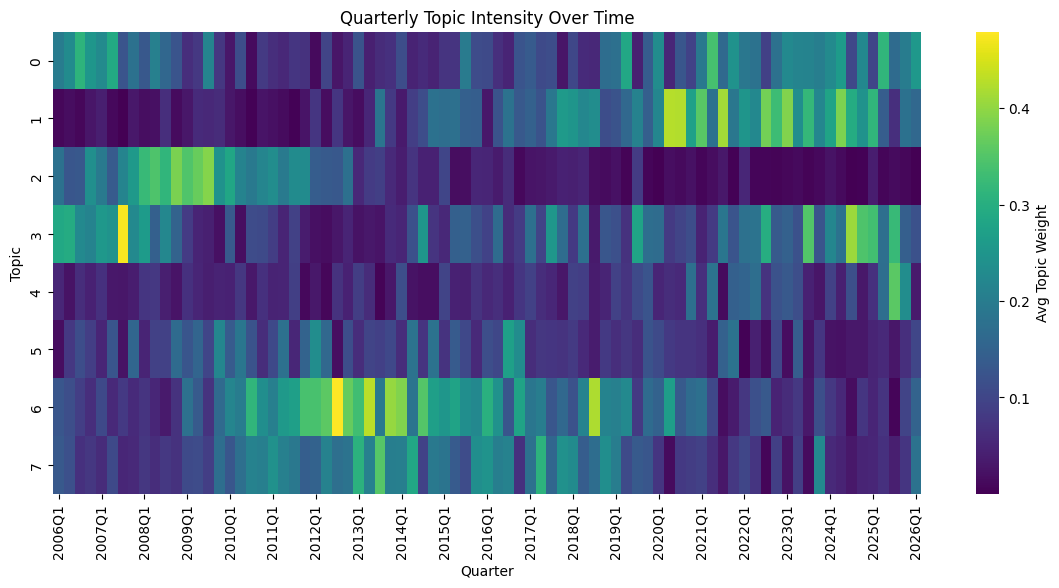

In [ ]:


plt.figure(figsize=(14,6))

sns.heatmap(
    quarterly_clean.T,
    cmap="viridis",
    cbar_kws={"label": "Avg Topic Weight"},
    xticklabels=4  # show every 4th quarter only
)

plt.title("Quarterly Topic Intensity Over Time")
plt.xlabel("Quarter")
plt.ylabel("Topic")
plt.show()

In [61]:
quarterly_smooth = quarterly_clean.rolling(2).mean()

<Figure size 1400x600 with 0 Axes>

<Axes: xlabel='year_month'>

Text(0.5, 1.0, 'Quarterly Topic Intensity Over Time')

Text(0.5, 36.72222222222221, 'Quarter')

Text(145.72222222222223, 0.5, 'Topic')

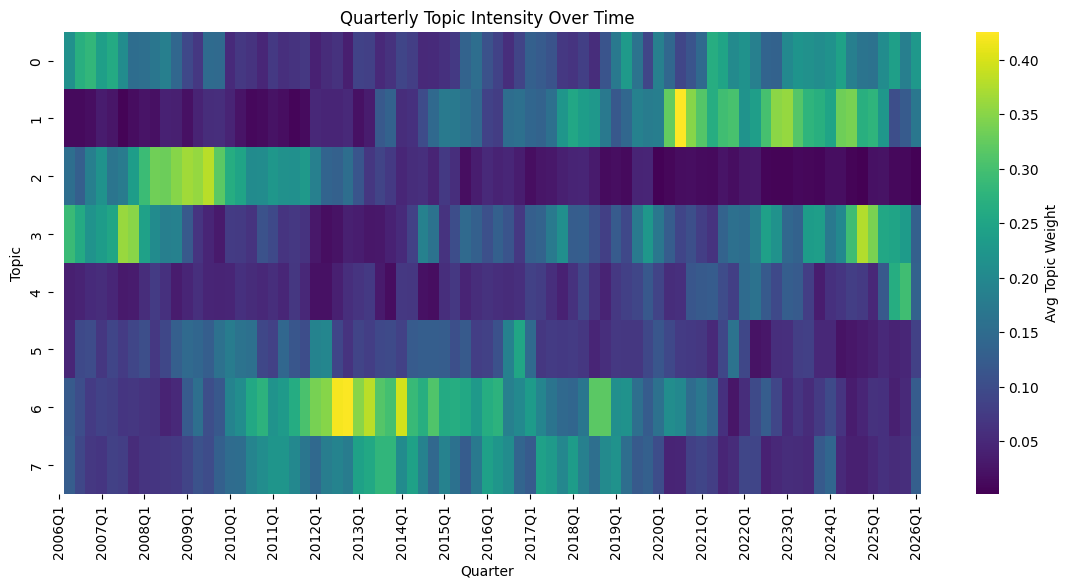

In [63]:

plt.figure(figsize=(14,6))

sns.heatmap(
    quarterly_smooth.T,
    cmap="viridis",
    cbar_kws={"label": "Avg Topic Weight"},
    xticklabels=4
)

plt.title("Quarterly Topic Intensity Over Time")
plt.xlabel("Quarter")
plt.ylabel("Topic")
plt.show()

In [67]:
quarterly_smooth_plot = quarterly_smooth.copy()
quarterly_smooth_plot.index = quarterly_smooth_plot.index.to_timestamp()

<Figure size 1400x600 with 0 Axes>

Text(0.5, 1.0, 'Evolution of Key Topics Over Time')

Text(0.5, 0, 'Quarter')

Text(0, 0.5, 'Average Topic Weight')

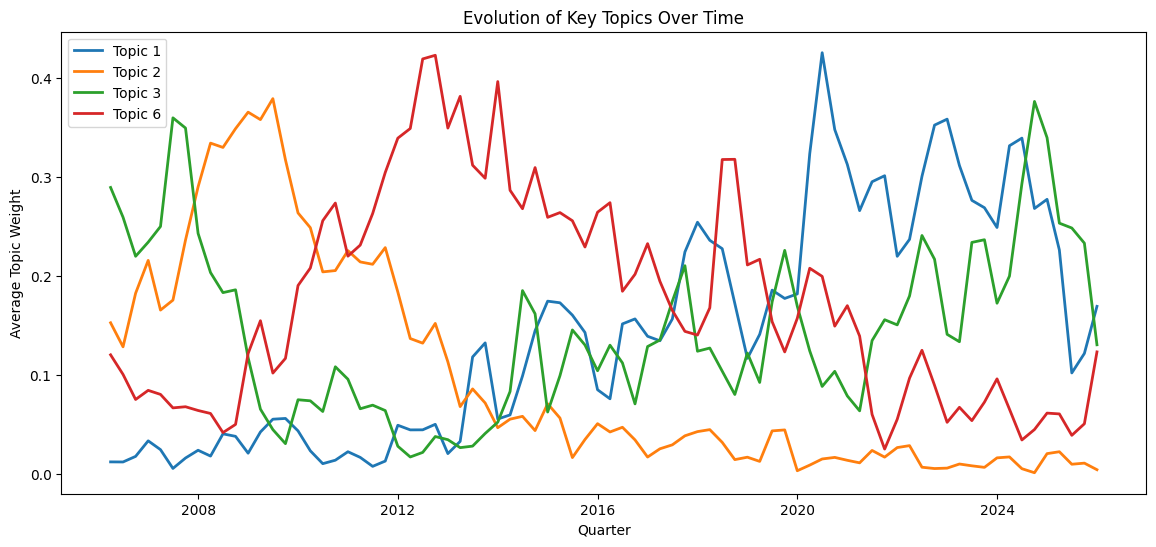

In [68]:
plt.figure(figsize=(14,6))

for topic in selected_topics:
    plt.plot(
        quarterly_smooth_plot.index,
        quarterly_smooth_plot[topic],
        linewidth=2,
        label=f"Topic {topic}"
    )

plt.title("Evolution of Key Topics Over Time")
plt.xlabel("Quarter")
plt.ylabel("Average Topic Weight")
plt.legend()
plt.show()

<Figure size 1400x600 with 0 Axes>

Text(0.5, 1.0, 'Evolution of Key ECB Communication Topics Over Time')

Text(0.5, 0, 'Quarter')

Text(0, 0.5, 'Average Topic Weight')

(array([12418., 13879., 15340., 16801., 18262., 19723., 21184.]),
 [Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

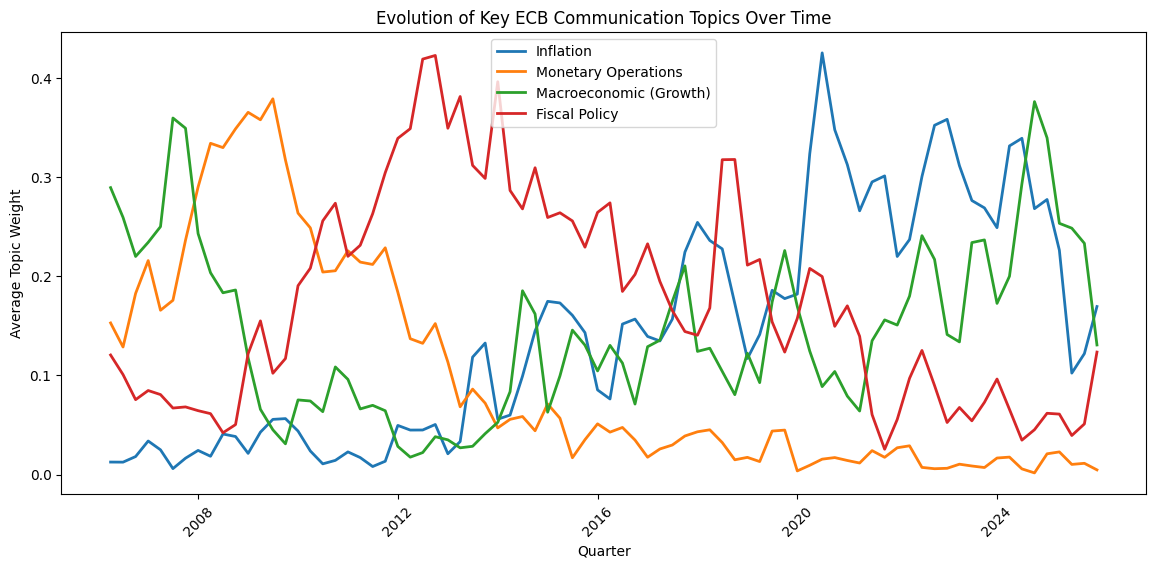

In [69]:
plt.figure(figsize=(14,6))

plt.plot(
    quarterly_smooth_plot.index,
    quarterly_smooth_plot[1],
    linewidth=2,
    label="Inflation"
)

plt.plot(
    quarterly_smooth_plot.index,
    quarterly_smooth_plot[2],
    linewidth=2,
    label="Monetary Operations"
)

plt.plot(
    quarterly_smooth_plot.index,
    quarterly_smooth_plot[3],
    linewidth=2,
    label="Macroeconomic (Growth)"
)

plt.plot(
    quarterly_smooth_plot.index,
    quarterly_smooth_plot[6],
    linewidth=2,
    label="Fiscal Policy"
)

plt.title("Evolution of Key ECB Communication Topics Over Time")
plt.xlabel("Quarter")
plt.ylabel("Average Topic Weight")
plt.legend()
plt.xticks(rotation=45)
plt.show()